In [5]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Load Iris dataset
data = load_iris()

X = data.data
y = data.target

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create Decision Tree model
dt_model = DecisionTreeClassifier()

# Train the model
dt_model.fit(X_train, y_train)

# Predict test data
y_pred = dt_model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy of Decision Tree Classifier: {accuracy}")

Accuracy of Decision Tree Classifier: 1.0


In [14]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# Read CSV file
df = pd.read_csv("fruit.csv")

# Input features
X = df[['mass', 'width', 'height', 'color_score']].values

# Output / target
y = df['fruit_name'].values

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Create Decision Tree model
dt_model = DecisionTreeClassifier()

# Train the model
dt_model.fit(X_train, y_train)

# Predict test data
y_pred = dt_model.predict(X_test)

# Get input from user
weight = float(input("Enter the Fruit weight in grams: "))
width = float(input("Enter the Fruit width: "))
height = float(input("Enter the Fruit height: "))
color_score = float(input("Enter the Fruit color score: "))

# Create new input row
newrow = np.array([[weight, width, height, color_score]])

# Predict fruit
prediction = dt_model.predict(newrow)

print("Predicted fruit:", prediction[0])

Enter the Fruit weight in grams:  150
Enter the Fruit width:  7
Enter the Fruit height:  7
Enter the Fruit color score:  7


Predicted fruit: apple


Columns in dataset:
['day', 'outlook', 'temperature', 'humidity', 'wind', 'play_cricket']

Dataset:
    day   outlook temperature humidity    wind play_cricket
0     1     Sunny         Hot     High    Weak           No
1     2     Sunny         Hot     High  Strong           No
2     3  Overcast         Hot     High    Weak          Yes
3     4     Rainy        Mild     High    Weak          Yes
4     5     Rainy        Cool   Normal    Weak          Yes
5     6     Rainy        Cool   Normal  Strong           No
6     7  Overcast        Cool   Normal  Strong          Yes
7     8     Sunny        Mild     High    Weak           No
8     9     Sunny        Cool   Normal    Weak          Yes
9    10     Rainy        Mild   Normal    Weak          Yes
10   11     Sunny        Mild   Normal  Strong          Yes
11   12  Overcast        Mild     High  Strong          Yes
12   13  Overcast         Hot   Normal    Weak          Yes
13   14     Rainy        Mild     High  Strong           No


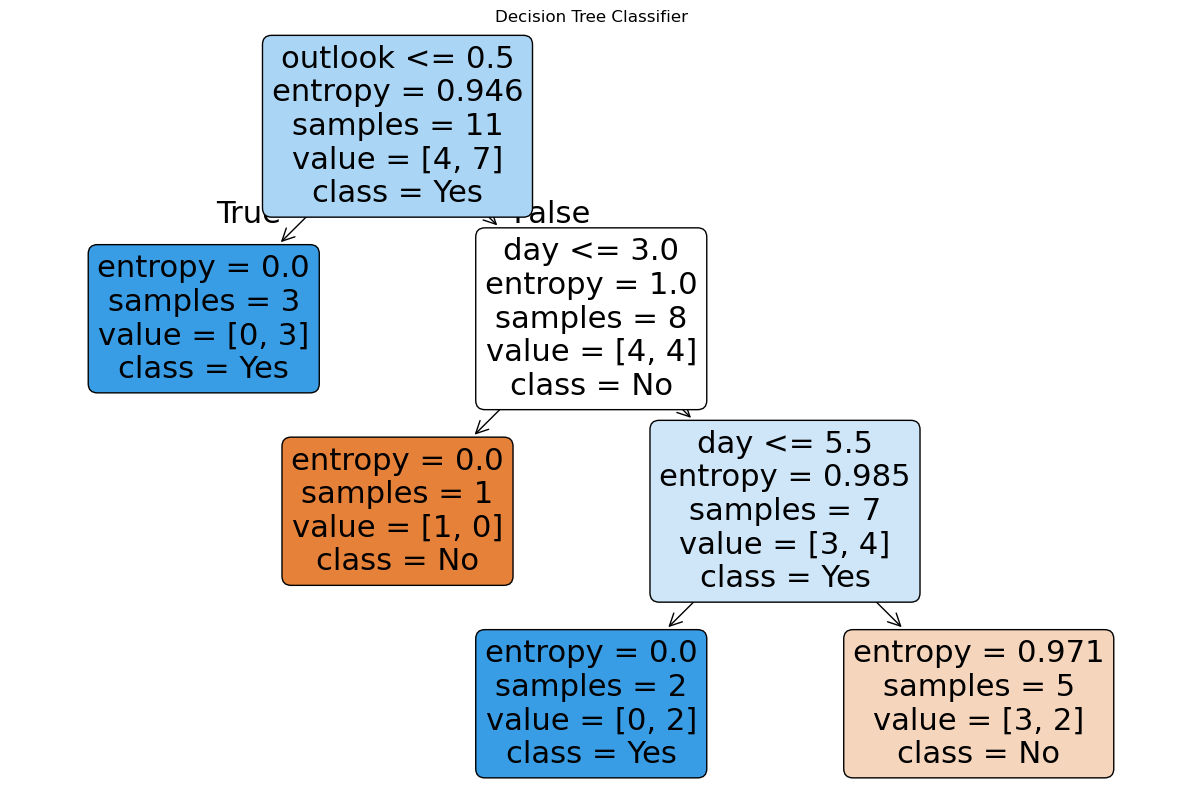

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

# Load dataset
df = pd.read_csv("dt.csv")

# Clean column names
df.columns = df.columns.str.strip().str.lower()

# Display column names
print("Columns in dataset:")
print(df.columns.tolist())

print("\nDataset:")
print(df)

# Remove missing values
df = df.dropna()

# ------------------------------------------------
# Input features
# ------------------------------------------------

# Use the first 3 columns as input features
X = df.iloc[:, 0:3].copy()

# Use the last column as target
y = df.iloc[:, -1].copy()

print("\nInput features:")
print(X.columns.tolist())

print("\nTarget column:")
print(df.columns[-1])

# ------------------------------------------------
# Encode categorical input columns
# ------------------------------------------------

label_encoders = {}

for column in X.columns:
    if X[column].dtype == "object":
        le = LabelEncoder()
        X[column] = le.fit_transform(X[column])
        label_encoders[column] = le

# Encode target column if it is categorical
target_encoder = None

if y.dtype == "object":
    target_encoder = LabelEncoder()
    y = target_encoder.fit_transform(y)

# ------------------------------------------------
# Split dataset
# ------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining data:")
print(X_train)

print("\nTesting data:")
print(X_test)

# ------------------------------------------------
# Create Decision Tree
# ------------------------------------------------

dt_model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=3,
    random_state=42
)

# Train model
dt_model.fit(X_train, y_train)

# ------------------------------------------------
# Prediction
# ------------------------------------------------

y_pred = dt_model.predict(X_test)

print("\nActual values:")
print(y_test)

print("\nPredicted values:")
print(y_pred)

# ------------------------------------------------
# Accuracy
# ------------------------------------------------

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy of Decision Tree Classifier:",
      round(accuracy, 2))

# ------------------------------------------------
# Visualize Decision Tree
# ------------------------------------------------

plt.figure(figsize=(15, 10))

# Get class names
if target_encoder is not None:
    class_names = [str(x) for x in target_encoder.classes_]
else:
    class_names = [str(x) for x in sorted(y.unique())]

plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=class_names,
    filled=True,
    rounded=True
)

plt.title("Decision Tree Classifier")
plt.show()

    Day   Outlook Temperature Humidity    Wind Play_Cricket
0     1     Sunny         Hot     High    Weak           No
1     2     Sunny         Hot     High  Strong           No
2     3  Overcast         Hot     High    Weak          Yes
3     4     Rainy        Mild     High    Weak          Yes
4     5     Rainy        Cool   Normal    Weak          Yes
5     6     Rainy        Cool   Normal  Strong           No
6     7  Overcast        Cool   Normal  Strong          Yes
7     8     Sunny        Mild     High    Weak           No
8     9     Sunny        Cool   Normal    Weak          Yes
9    10     Rainy        Mild   Normal    Weak          Yes
10   11     Sunny        Mild   Normal  Strong          Yes
11   12  Overcast        Mild     High  Strong          Yes
12   13  Overcast         Hot   Normal    Weak          Yes
13   14     Rainy        Mild     High  Strong           No
 
 Accuracy of Decision Tree Classifier: 0.33


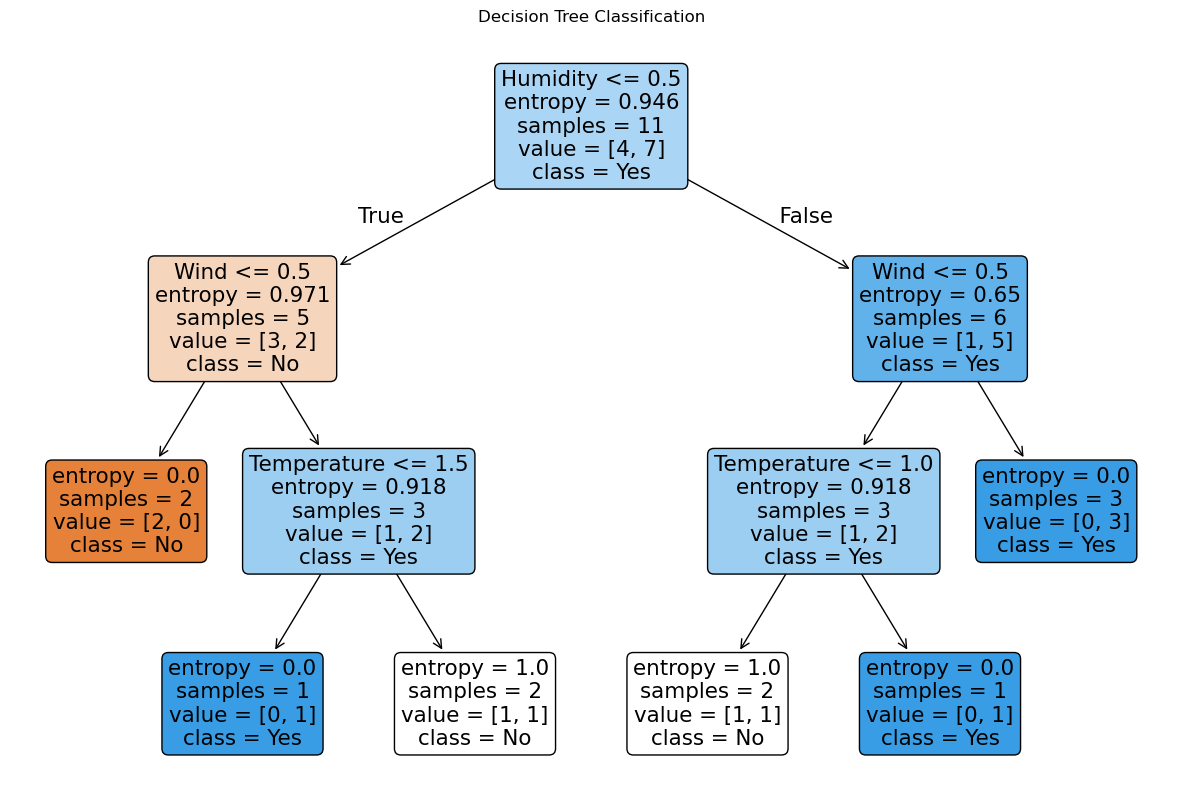

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

# Load your dataset
df=pd.read_csv('dt.csv')

print(df)

le_temperature = LabelEncoder()
le_humidity = LabelEncoder()
le_wind = LabelEncoder()
le_play = LabelEncoder()

df["Temperature"] = le_temperature.fit_transform(df["Temperature"])
df["Humidity"] = le_humidity.fit_transform(df["Humidity"])
df["Wind"] = le_wind.fit_transform(df["Wind"])
df["Play_Cricket"] = le_play.fit_transform(df["Play_Cricket"])

X = df[["Temperature", "Humidity", "Wind"]]
y = df["Play_Cricket"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=3,
    random_state=42
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f" \n Accuracy of Decision Tree Classifier: {accuracy:.2f}")
plt.figure(figsize=(15, 10))

plot_tree(
    model,
    feature_names=["Temperature", "Humidity", "Wind"],
    class_names=list(le_play.classes_),
    filled=True,
    rounded=True
)
plt.title("Decision Tree Classification")
plt.show()